In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
from pydantic import BaseModel, model_validator
from typing import ClassVar
from matplotlib import axes

from freeze_thaw.data_preparation import ascat_era5 as utils
from freeze_thaw.utils import find_repo_root
from freeze_thaw.data_preparation.general import filter_df, add_class_col
from freeze_thaw.validation import validate_time_index, check_df_cols
from freeze_thaw.data_understanding.visualization import plot_var_vs_time
from freeze_thaw.config import config as c
from freeze_thaw.config import StationName

# Data Understanding and Preparation of the ASCAT and ERA5 Data

The goal is to generate descriptive statistics, drop missing values & outliers, interpolate ERA5 data based on time so that it's hourly, and plot the data for all ASCAT and ERA5 data in `raw_path / ASCAT` and `raw_path / ERA5`. The cleaned data will then be exported to their respective folders in `c.CLEANED_DATA_PATH`.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [2]:
class NotebookVariables(BaseModel):
    """DO NOT EDIT THIS CLASS."""
    ASCAT_short_var_name: str = 'backscatter40'
    ERA5_short_var_name: str = 'stl1'
    ASCAT_long_var_name: str = '40° Normalized Backscatter (dB)'
    ERA5_long_var_name: str = 'Soil Temperature Level 1 (C)'

    START: datetime = datetime(2010, 6, 1)
    END: datetime = datetime(2011, 6, 1)

    ASCAT: ClassVar[str] = 'ASCAT'
    ERA5: ClassVar[str] = 'ERA5'

    raw_path: Path = find_repo_root() / "data" / "raw" / "ASCAT_ERA5"

    @model_validator(mode="after")
    def validate(self):
        if not self.raw_path.is_dir():
            raise NotADirectoryError(f'{self.raw_path} must point to a directory.')
        return self

# example for editing values: NotebookVariables(raw_path = find_repo_root() / "data" / "raw")
nb_vars = NotebookVariables()

### 1.2 Functions

In [3]:
def data_cleaning(data_path: Path,
                  ismn_sites_path: Path,
                  station: StationName,
                  system: str,
                  key_variable: str,
                  drop_na: bool = False,
                  class_boundary=None,
                  classes=None,
                  date_range=None) -> pd.DataFrame:
    """
    Preprocessing of raw ASCAT or ERA5 data.
    :param data_path: path to csv file
    :param ismn_sites_path: path to csv file containing ISMN site information
    :param station: must match exactly name in ISMN_site_survey.csv
    :param system: ASCAT or nb_vars.ERA5, case-insensitive
    :param key_variable: name of variable of interest (in csv)
    :param drop_na: whether to drop rows with NaNs in key columns
    :param class_boundary: in C; creates a symmetric boundary across the freezing point for class labeling
    :param classes: list of exactly length three containing only str elements
    :param date_range: DateRange class. Data outside this range is filtered out. Start is inclusive and end is exclusive. Assumed that input is in the same timezone as df.index. If date_range is not valid for given df, date_range will be adjusted to be valid.
    :return: cleaned dataframe
    """
    # load data
    df = utils.collect_data(data_path, ismn_sites_path, station, system)
    check_df_cols(df, system)

    # report NaN count and proportion
    na_count = df.isnull().sum()[key_variable]
    print(f'There are {na_count} nulls out of {len(df)} datapoints ({round(na_count/len(df),2)}% missing).')

    # data preprocessing
    if drop_na:
        df = df.dropna(subset=[key_variable])
    df = utils.round_nearest_hour_index(df, c.DATETIMEINDEX_NAME, system)
    if date_range is not None:
        df = filter_df(df, date_range.start, date_range.end)

    # only keep required columns
    if system.upper() == 'ASCAT':
        if c.ASCAT_KEY_COLS is not None:
            df = df[c.ASCAT_KEY_COLS]
    if system.upper() == 'ERA5':
        if c.ERA5_KEY_COLS is not None:
            df = df[c.ERA5_KEY_COLS]

    # data imputation for ERA5 data to go from values every 6 hours to every 1 hour
    # add predicted class column
    if system.upper() == 'ERA5':
        df = utils.impute_hourly(df)
        if class_boundary is not None and classes is not None:
            df = add_class_col(df, key_variable, "pred")

    return df

def data_reporting(df: pd.DataFrame, variable: str, ylabel: str) -> axes:
    """
    Reporting of preprocessed ASCAT and ERA5 data.
    :param df: can be output from soil_temp_data_cleaning()
    :param variable: full variable name
    :param ylabel: y-label for plot
    :return: matplotlib.axes object
    """
    # check data types
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f'df must be a pd.DataFrame, not {type(df)}.')
    # check input values
    if variable not in df.columns:
        raise KeyError(f'df missing required column "{variable}".')
    # check input df index
    validate_time_index(df)

    print('Summary statistics:')
    display(df.describe())
    print('Show head of df:')
    display(df.head())

    ax = plot_var_vs_time(df, variable, form='line', y_label=ylabel)

    return ax

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

#### ASCAT

There are 1618 nulls out of 17799 datapoints (0.09% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,15727.000000,17182.000000,17182.000000,17182.000000
mean,-14.761969,0.490222,0.502386,3.704749
std,1.718559,0.499919,0.500009,0.733953
min,-19.637800,0.000000,0.000000,3.000000
25%,-15.930315,0.000000,0.000000,3.000000
50%,-14.602778,0.000000,1.000000,4.000000
75%,-13.591239,1.000000,1.000000,4.000000
max,-6.488361,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 04:00:00+00:00,-18.138327,1,0,3
2007-01-02 04:00:00+00:00,-18.249712,1,0,3
2007-01-02 16:00:00+00:00,-18.546434,1,1,3
2007-01-03 17:00:00+00:00,-17.615808,0,1,3
2007-01-04 03:00:00+00:00,-15.992000,0,0,3


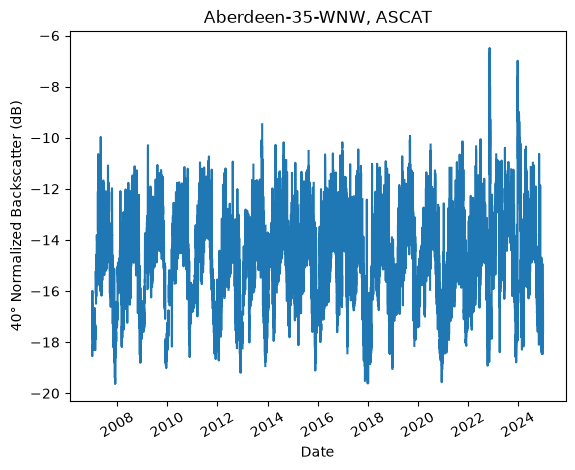

In [4]:
ASCAT_aberdeen_df = data_cleaning(data_path=nb_vars.raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=StationName.ABERDEEN,
                                  system=nb_vars.ASCAT,
                                  key_variable=nb_vars.ASCAT_short_var_name,
                                  date_range=c.DATE_RANGE)

ax = data_reporting(df=ASCAT_aberdeen_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f'{StationName.ABERDEEN}, {nb_vars.ASCAT}')

Plot one year of ASCAT data to determine backscatter behavior for this location

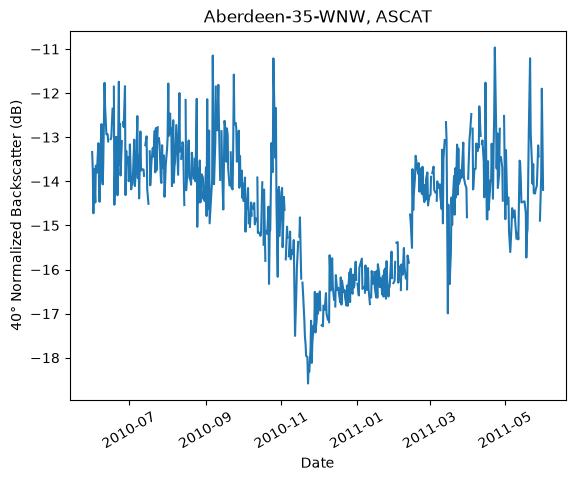

In [5]:
ax = plot_var_vs_time(ASCAT_aberdeen_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.ABERDEEN}, {nb_vars.ASCAT}")

In [6]:
# export to csv
ASCAT_aberdeen_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.ABERDEEN}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,8.076773
std,10.985569
min,-25.262360
25%,-1.368602
50%,7.280548
75%,18.006943
max,33.542816


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-3.689606,frozen
2007-01-01 01:00:00+00:00,-4.181793,frozen
2007-01-01 02:00:00+00:00,-4.673981,frozen
2007-01-01 03:00:00+00:00,-5.166168,frozen
2007-01-01 04:00:00+00:00,-5.658356,frozen


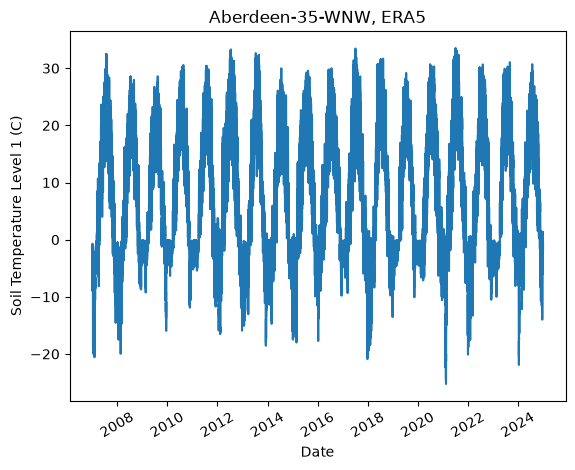

In [7]:
ERA5_aberdeen_df = data_cleaning(data_path=nb_vars.raw_path,
                                 ismn_sites_path=c.SITE_SURVEY_PATH,
                                 station=StationName.ABERDEEN,
                                 system=nb_vars.ERA5,
                                 key_variable=nb_vars.ERA5_short_var_name,
                                 class_boundary=c.CLASS_BOUNDARY,
                                 classes=c.CLASSES,
                                 date_range=c.DATE_RANGE)

ax = data_reporting(df=ERA5_aberdeen_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.ABERDEEN}, {nb_vars.ERA5}")

In [8]:
# export to csv
ERA5_aberdeen_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.ABERDEEN}_{nb_vars.ERA5}.csv')

### 2.2 Jamestown-38-WSW

#### ASCAT

There are 2199 nulls out of 18830 datapoints (0.12% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,16110.000000,17931.000000,17931.000000,17931.000000
mean,-14.565009,0.490380,0.486587,3.701746
std,1.584991,0.499921,0.499834,0.734267
min,-19.451506,0.000000,0.000000,3.000000
25%,-15.595675,0.000000,0.000000,3.000000
50%,-14.441017,0.000000,0.000000,4.000000
75%,-13.450079,1.000000,1.000000,4.000000
max,-6.382537,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 04:00:00+00:00,-18.511513,1,0,3
2007-01-02 04:00:00+00:00,-18.238005,1,0,3
2007-01-02 16:00:00+00:00,-18.214222,1,1,3
2007-01-03 17:00:00+00:00,-15.158000,0,1,3
2007-01-04 03:00:00+00:00,-14.611470,0,0,3


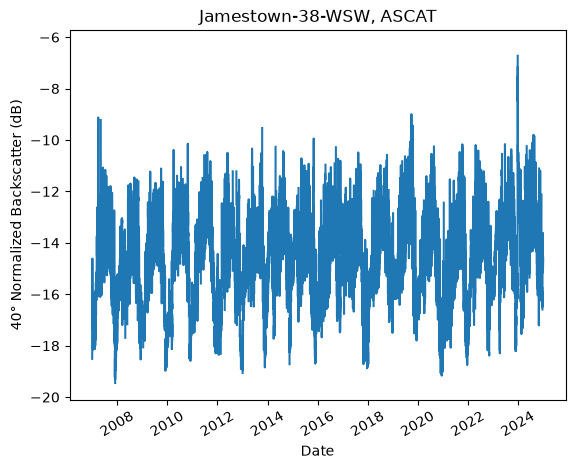

In [9]:
ASCAT_jamestown_df = data_cleaning(data_path=nb_vars.raw_path,
                                   ismn_sites_path=c.SITE_SURVEY_PATH,
                                   station=StationName.JAMESTOWN,
                                   system=nb_vars.ASCAT,
                                   key_variable=nb_vars.ASCAT_short_var_name,
                                   date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_jamestown_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.JAMESTOWN}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

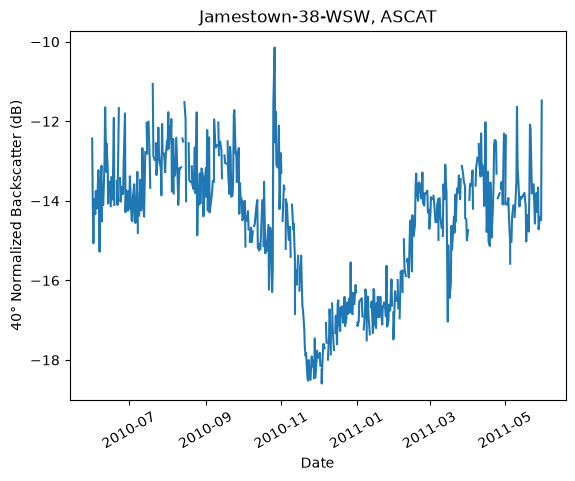

In [10]:
ax = plot_var_vs_time(ASCAT_jamestown_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.JAMESTOWN}, {nb_vars.ASCAT}")

In [11]:
# export to csv
ASCAT_jamestown_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.JAMESTOWN}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,7.526758
std,10.847192
min,-25.742828
25%,-1.559113
50%,6.577789
75%,17.233581
max,34.929596


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-4.855621,frozen
2007-01-01 01:00:00+00:00,-5.320465,frozen
2007-01-01 02:00:00+00:00,-5.785309,frozen
2007-01-01 03:00:00+00:00,-6.250153,frozen
2007-01-01 04:00:00+00:00,-6.714996,frozen


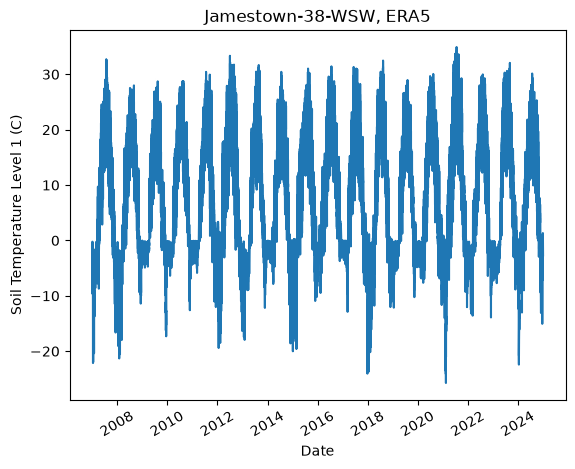

In [12]:
ERA5_jamestown_df = data_cleaning(data_path=nb_vars.raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=StationName.JAMESTOWN,
                                  system=nb_vars.ERA5,
                                  key_variable=nb_vars.ERA5_short_var_name,
                                  class_boundary=c.CLASS_BOUNDARY,
                                  classes=c.CLASSES,
                                  date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_jamestown_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.JAMESTOWN}, {nb_vars.ERA5}")

In [13]:
# export to csv
ERA5_jamestown_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.JAMESTOWN}_{nb_vars.ERA5}.csv')

### 2.3 Gobblers Knob

#### ASCAT

There are 3620 nulls out of 36140 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,28972.000000,30933.000000,30933.000000,30933.000000
mean,-11.649598,0.440597,0.488443,3.687971
std,1.477601,0.496467,0.499874,0.738993
min,-15.863902,0.000000,0.000000,3.000000
25%,-12.981206,0.000000,0.000000,3.000000
50%,-11.867991,0.000000,0.000000,4.000000
75%,-10.226372,1.000000,1.000000,4.000000
max,-7.769168,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 08:00:00+00:00,NaN,1,0,3
2007-01-01 20:00:00+00:00,-12.790222,1,1,3
2007-01-01 21:00:00+00:00,NaN,0,1,3
2007-01-02 06:00:00+00:00,-13.280205,0,0,3
2007-01-02 07:00:00+00:00,-12.628483,1,0,3


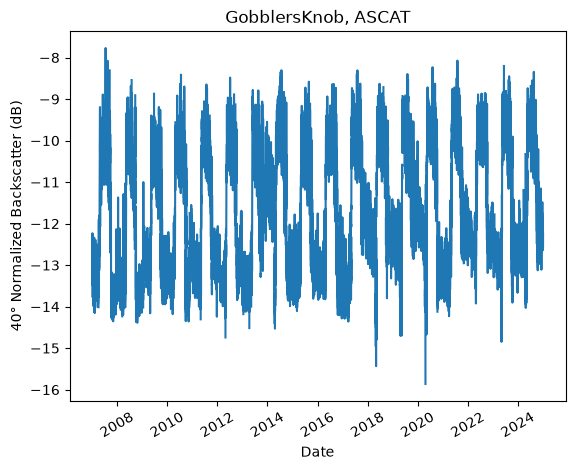

In [14]:
ASCAT_gobblers_knob_df = data_cleaning(data_path=nb_vars.raw_path,
                                       ismn_sites_path=c.SITE_SURVEY_PATH,
                                       station=StationName.GOBBLERS_KNOB,
                                       system=nb_vars.ASCAT,
                                       key_variable=nb_vars.ASCAT_short_var_name,
                                       date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_gobblers_knob_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.GOBBLERS_KNOB}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

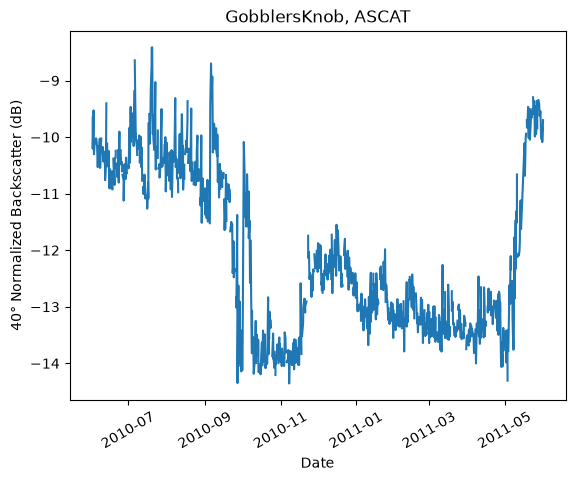

In [15]:
ax = plot_var_vs_time(ASCAT_gobblers_knob_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.GOBBLERS_KNOB}, {nb_vars.ASCAT}")

In [16]:
# export to csv
ASCAT_gobblers_knob_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.GOBBLERS_KNOB}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,1.721689
std,7.909537
min,-32.260240
25%,-3.299713
50%,-0.866791
75%,8.660706
max,25.048218


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-1.519684,frozen
2007-01-01 01:00:00+00:00,-1.662587,frozen
2007-01-01 02:00:00+00:00,-1.805491,frozen
2007-01-01 03:00:00+00:00,-1.948395,frozen
2007-01-01 04:00:00+00:00,-2.091298,frozen


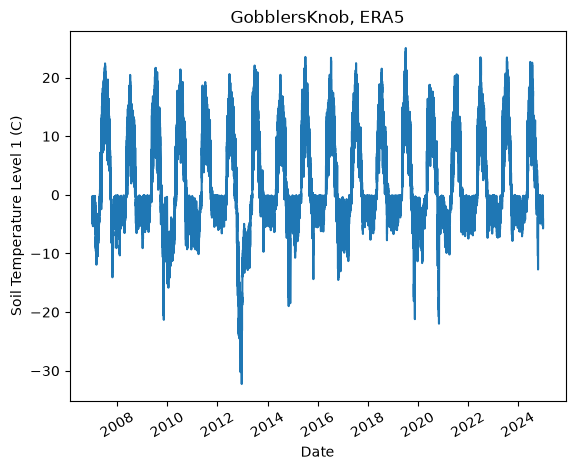

In [17]:
ERA5_gobblers_knob_df = data_cleaning(data_path=nb_vars.raw_path,
                                      ismn_sites_path=c.SITE_SURVEY_PATH,
                                      station=StationName.GOBBLERS_KNOB,
                                      system=nb_vars.ERA5,
                                      key_variable=nb_vars.ERA5_short_var_name,
                                      class_boundary=c.CLASS_BOUNDARY,
                                      classes=c.CLASSES,
                                      date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_gobblers_knob_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.GOBBLERS_KNOB}, {nb_vars.ERA5}")

In [18]:
# export to csv
ERA5_gobblers_knob_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.GOBBLERS_KNOB}_{nb_vars.ERA5}.csv')

### 2.4 Nenana

#### ASCAT

There are 3433 nulls out of 32538 datapoints (0.11% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,27200.000000,29744.000000,29744.000000,29744.000000
mean,-10.735387,0.448662,0.521147,3.699738
std,1.214230,0.497366,0.499561,0.737362
min,-13.780949,0.000000,0.000000,3.000000
25%,-11.801000,0.000000,0.000000,3.000000
50%,-10.604760,0.000000,1.000000,4.000000
75%,-9.635055,1.000000,1.000000,4.000000
max,-7.459589,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 20:00:00+00:00,-11.646178,1,1,3
2007-01-01 21:00:00+00:00,-12.336268,0,1,3
2007-01-02 06:00:00+00:00,-12.234253,0,0,3
2007-01-02 07:00:00+00:00,-11.359132,1,0,3
2007-01-02 19:00:00+00:00,-11.386372,1,1,3


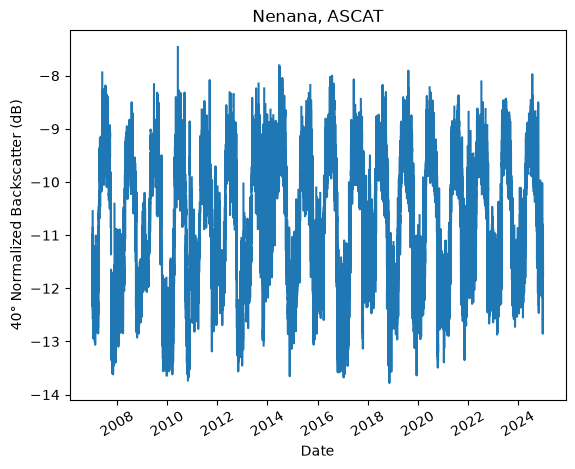

In [19]:
ASCAT_nenana_df = data_cleaning(data_path=nb_vars.raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=StationName.NENANA,
                                system=nb_vars.ASCAT,
                                key_variable=nb_vars.ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_nenana_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.NENANA}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

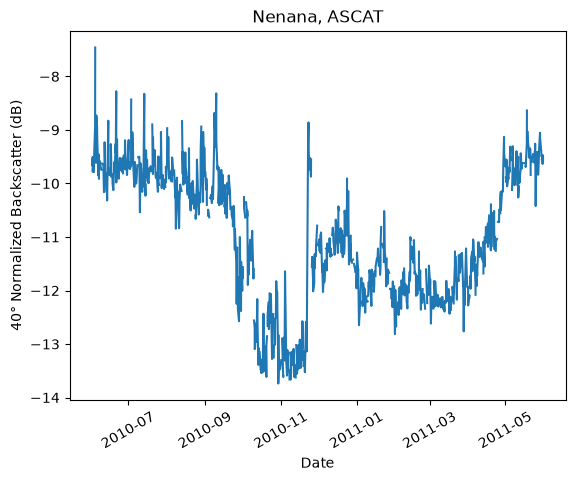

In [20]:
ax = plot_var_vs_time(ASCAT_nenana_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.NENANA}, {nb_vars.ASCAT}")

In [21]:
# export to csv
ASCAT_nenana_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.NENANA}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,2.152180
std,10.986284
min,-34.949005
25%,-5.701019
50%,-0.542826
75%,12.205068
max,29.949066


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-14.547028,frozen
2007-01-01 01:00:00+00:00,-14.726064,frozen
2007-01-01 02:00:00+00:00,-14.905101,frozen
2007-01-01 03:00:00+00:00,-15.084137,frozen
2007-01-01 04:00:00+00:00,-15.263173,frozen


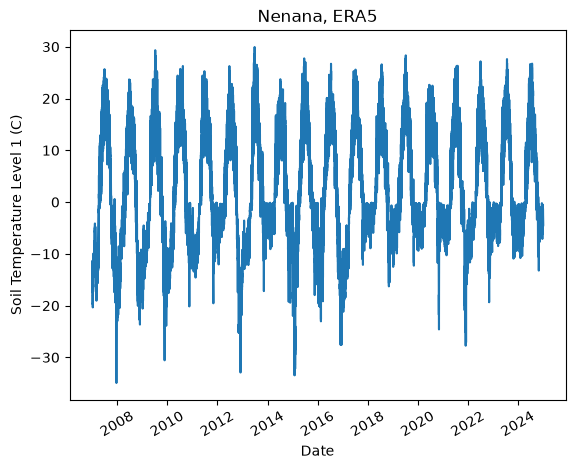

In [22]:
ERA5_nenana_df = data_cleaning(data_path=nb_vars.raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=StationName.NENANA,
                               system=nb_vars.ERA5,
                               key_variable=nb_vars.ERA5_short_var_name,
                               class_boundary=c.CLASS_BOUNDARY,
                               classes=c.CLASSES,
                               date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_nenana_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.NENANA}, {nb_vars.ERA5}")

In [23]:
# export to csv
ERA5_nenana_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.NENANA}_{nb_vars.ERA5}.csv')

### 2.5 L23

#### ASCAT

There are 874 nulls out of 14374 datapoints (0.06% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,12415.000000,13055.000000,13055.000000,13055.000000
mean,-11.806786,0.460743,0.525546,3.682421
std,1.497051,0.498476,0.499366,0.734438
min,-16.494514,0.000000,0.000000,3.000000
25%,-13.086704,0.000000,0.000000,3.000000
50%,-11.976106,0.000000,1.000000,4.000000
75%,-10.503549,1.000000,1.000000,4.000000
max,-7.121807,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 04:00:00+00:00,-12.918723,0,1,3
2007-01-02 16:00:00+00:00,-12.326420,1,0,3
2007-01-03 04:00:00+00:00,-14.347024,0,1,3
2007-01-03 15:00:00+00:00,-13.486931,1,0,3
2007-01-05 03:00:00+00:00,-13.790267,1,1,3


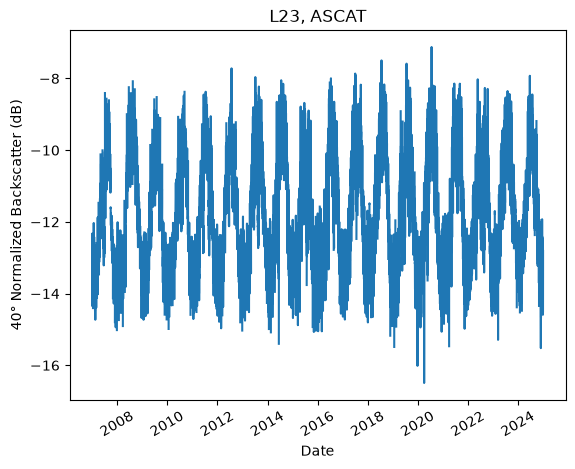

In [24]:
ASCAT_L23_df = data_cleaning(data_path=nb_vars.raw_path,
                             ismn_sites_path=c.SITE_SURVEY_PATH,
                             station=StationName.L23,
                             system=nb_vars.ASCAT,
                             key_variable=nb_vars.ASCAT_short_var_name,
                             date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_L23_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.L23}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

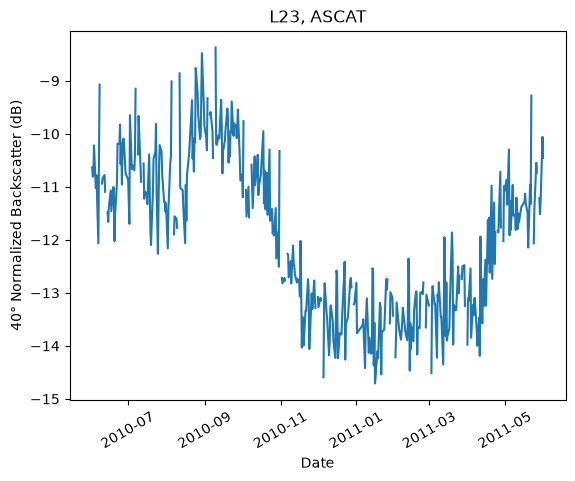

In [25]:
ax = plot_var_vs_time(ASCAT_L23_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.L23}, {nb_vars.ASCAT}")

In [26]:
# export to csv
ASCAT_L23_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.L23}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,0.426475
std,6.085473
min,-14.649292
25%,-4.151448
50%,-1.242142
75%,5.490082
max,17.009247


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-4.203278,frozen
2007-01-01 01:00:00+00:00,-4.197418,frozen
2007-01-01 02:00:00+00:00,-4.191559,frozen
2007-01-01 03:00:00+00:00,-4.185700,frozen
2007-01-01 04:00:00+00:00,-4.179840,frozen


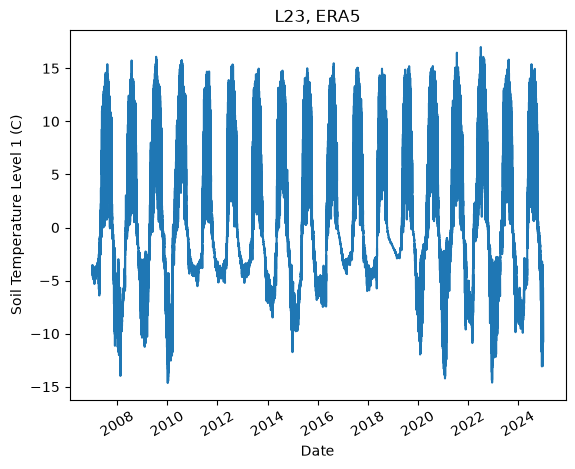

In [27]:
ERA5_L23_df = data_cleaning(data_path=nb_vars.raw_path,
                            ismn_sites_path=c.SITE_SURVEY_PATH,
                            station=StationName.L23,
                            system=nb_vars.ERA5,
                            key_variable=nb_vars.ERA5_short_var_name,
                            class_boundary=c.CLASS_BOUNDARY,
                            classes=c.CLASSES,
                            date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_L23_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.L23}, {nb_vars.ERA5}")

In [28]:
# export to csv
ERA5_L23_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.L23}_{nb_vars.ERA5}.csv')

### 2.6 L38

#### ASCAT

There are 1594 nulls out of 14489 datapoints (0.11% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,11658.000000,13034.000000,13034.000000,13034.000000
mean,-11.823684,0.454964,0.523554,3.686589
std,1.175492,0.497987,0.499464,0.736041
min,-15.653297,0.000000,0.000000,3.000000
25%,-12.848439,0.000000,0.000000,3.000000
50%,-11.997737,0.000000,1.000000,4.000000
75%,-10.825613,1.000000,1.000000,4.000000
max,-7.204072,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 04:00:00+00:00,-13.265300,0,1,3
2007-01-02 16:00:00+00:00,-13.208417,1,0,3
2007-01-03 04:00:00+00:00,-13.032414,0,1,3
2007-01-03 15:00:00+00:00,-13.790648,1,0,3
2007-01-05 03:00:00+00:00,-13.257554,1,1,3


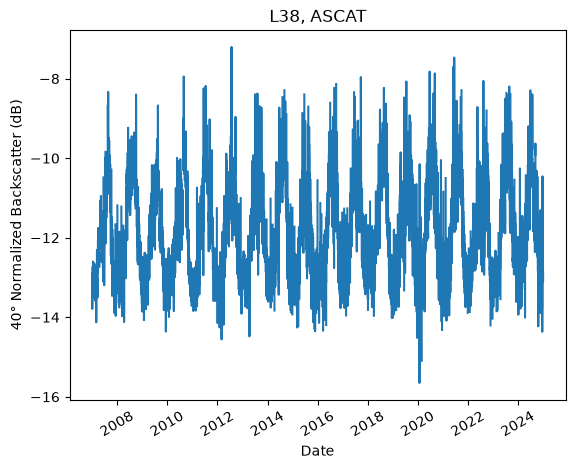

In [29]:
ASCAT_L38_df = data_cleaning(data_path=nb_vars.raw_path,
                             ismn_sites_path=c.SITE_SURVEY_PATH,
                             station=StationName.L38,
                             system=nb_vars.ASCAT,
                             key_variable=nb_vars.ASCAT_short_var_name,
                             date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_L38_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.L38}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

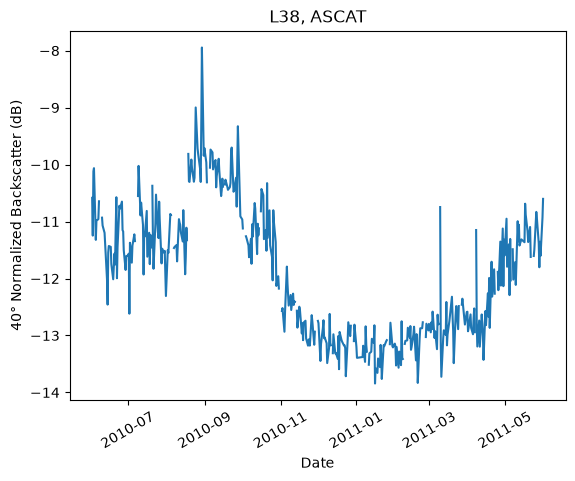

In [30]:
ax = plot_var_vs_time(ASCAT_L38_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.L38}, {nb_vars.ASCAT}")

In [31]:
# export to csv
ASCAT_L38_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.L38}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,0.493749
std,6.428395
min,-18.951782
25%,-3.984690
50%,-0.778702
75%,5.804392
max,17.397919


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-4.507965,frozen
2007-01-01 01:00:00+00:00,-4.492991,frozen
2007-01-01 02:00:00+00:00,-4.478017,frozen
2007-01-01 03:00:00+00:00,-4.463043,frozen
2007-01-01 04:00:00+00:00,-4.448069,frozen


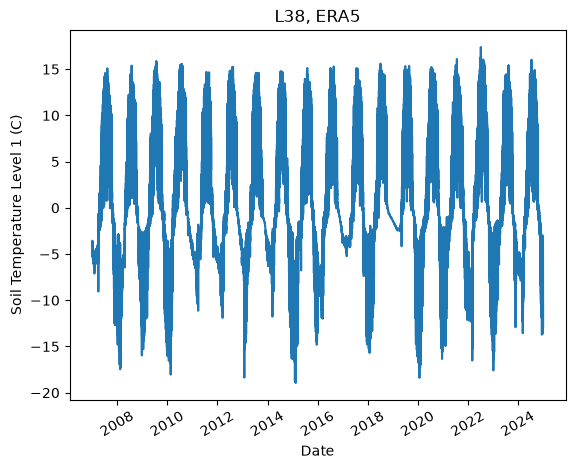

In [32]:
ERA5_L38_df = data_cleaning(data_path=nb_vars.raw_path,
                            ismn_sites_path=c.SITE_SURVEY_PATH,
                            station=StationName.L38,
                            system=nb_vars.ERA5,
                            key_variable=nb_vars.ERA5_short_var_name,
                            class_boundary=c.CLASS_BOUNDARY,
                            classes=c.CLASSES,
                            date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_L38_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.L38}, {nb_vars.ERA5}")

In [33]:
# export to csv
ERA5_L38_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.L38}_{nb_vars.ERA5}.csv')

### 2.7 NST-07

#### ASCAT

There are 1049 nulls out of 15088 datapoints (0.07% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,12813.000000,13797.000000,13797.000000,13797.000000
mean,-13.733412,0.495905,0.483656,3.714358
std,2.183471,0.500001,0.499751,0.746951
min,-18.695620,0.000000,0.000000,3.000000
25%,-15.681290,0.000000,0.000000,3.000000
50%,-12.998567,0.000000,0.000000,4.000000
75%,-11.946377,1.000000,1.000000,4.000000
max,-9.411098,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 03:00:00+00:00,-18.340450,1,1,3
2007-01-02 14:00:00+00:00,-17.415730,0,0,3
2007-01-03 14:00:00+00:00,-16.352602,0,0,3
2007-01-04 04:00:00+00:00,-18.040010,0,1,3
2007-01-04 15:00:00+00:00,-17.644730,1,0,3


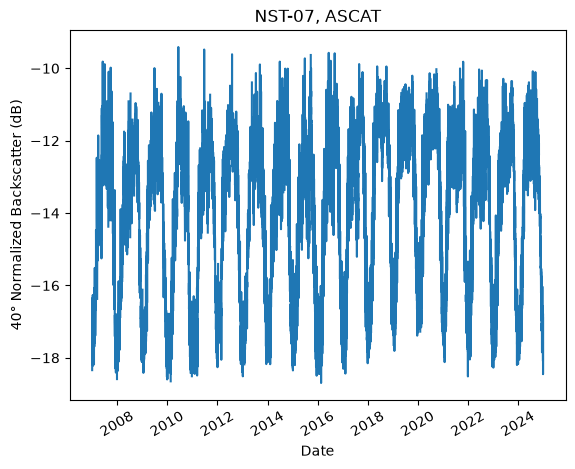

In [34]:
ASCAT_NST_07_df = data_cleaning(data_path=nb_vars.raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=StationName.NST_07,
                                system=nb_vars.ASCAT,
                                key_variable=nb_vars.ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_NST_07_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.NST_07}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

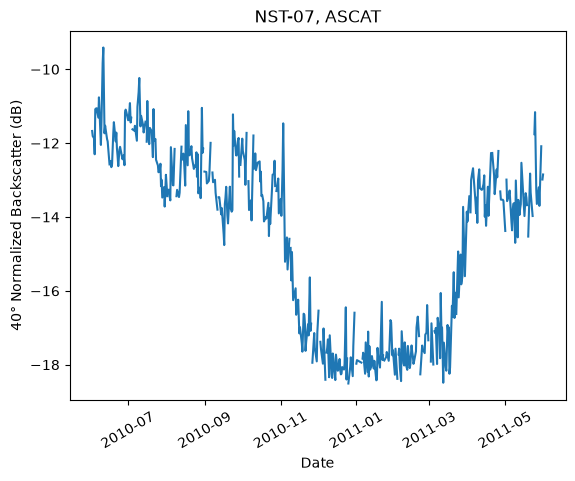

In [35]:
ax = plot_var_vs_time(ASCAT_NST_07_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.NST_07}, {nb_vars.ASCAT}")

In [36]:
# export to csv
ASCAT_NST_07_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.NST_07}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,3.110197
std,6.995257
min,-17.119934
25%,-2.210663
50%,2.231110
75%,9.081574
max,22.347748


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-11.910309,frozen
2007-01-01 01:00:00+00:00,-10.904775,frozen
2007-01-01 02:00:00+00:00,-9.899241,frozen
2007-01-01 03:00:00+00:00,-8.893707,frozen
2007-01-01 04:00:00+00:00,-7.888173,frozen


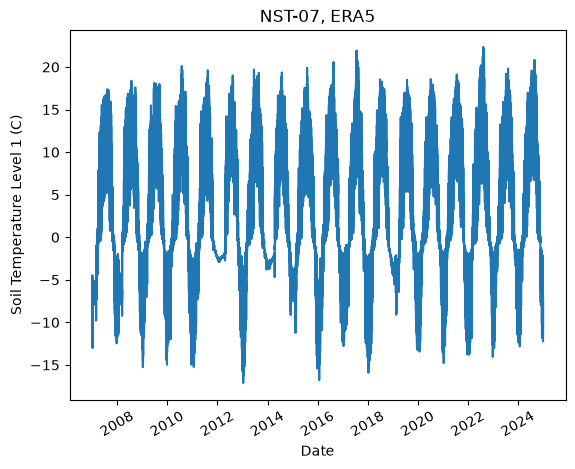

In [37]:
ERA5_NST_07_df = data_cleaning(data_path=nb_vars.raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=StationName.NST_07,
                               system=nb_vars.ERA5,
                               key_variable=nb_vars.ERA5_short_var_name,
                               class_boundary=c.CLASS_BOUNDARY,
                               classes=c.CLASSES,
                               date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_NST_07_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.NST_07}, {nb_vars.ERA5}")

In [38]:
# export to csv
ERA5_NST_07_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.NST_07}_{nb_vars.ERA5}.csv')

### 2.8 NST-09

#### ASCAT

There are 1423 nulls out of 14768 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,12131.000000,13459.000000,13459.000000,13459.000000
mean,-13.620912,0.508210,0.492756,3.714169
std,2.150856,0.499951,0.499966,0.747782
min,-19.681623,0.000000,0.000000,3.000000
25%,-15.399235,0.000000,0.000000,3.000000
50%,-12.928908,1.000000,0.000000,4.000000
75%,-11.859486,1.000000,1.000000,4.000000
max,-9.696083,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 03:00:00+00:00,-18.221373,1,1,3
2007-01-02 14:00:00+00:00,-17.126863,0,0,3
2007-01-03 14:00:00+00:00,-15.837445,0,0,3
2007-01-04 04:00:00+00:00,-17.808882,0,1,3
2007-01-04 15:00:00+00:00,-17.277155,1,0,3


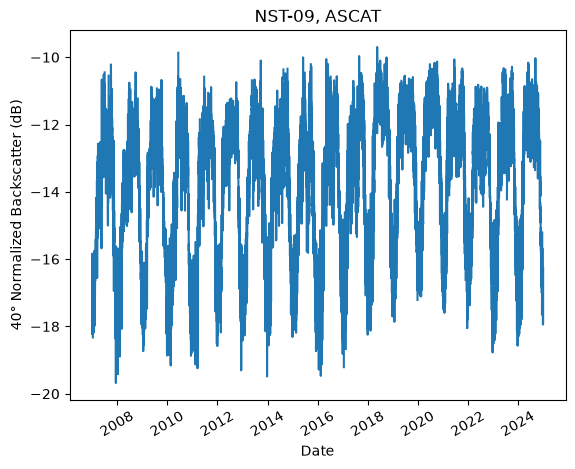

In [39]:
ASCAT_NST_09_df = data_cleaning(data_path=nb_vars.raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=StationName.NST_09,
                                system=nb_vars.ASCAT,
                                key_variable=nb_vars.ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_NST_09_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.NST_09}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

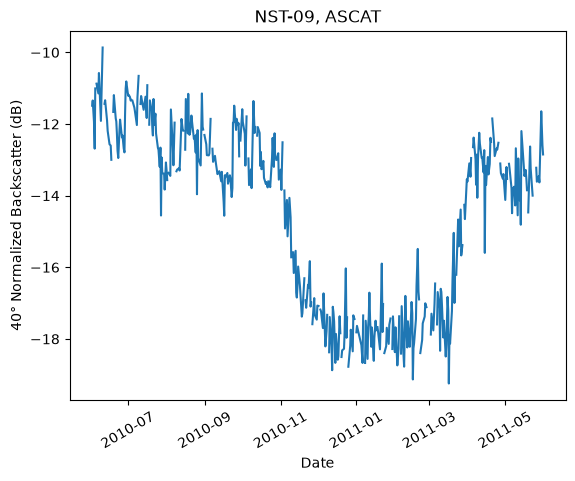

In [40]:
ax = plot_var_vs_time(ASCAT_NST_09_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.NST_09}, {nb_vars.ASCAT}")

In [41]:
# export to csv
ASCAT_NST_09_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.NST_09}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,3.110197
std,6.995257
min,-17.119934
25%,-2.210663
50%,2.231110
75%,9.081574
max,22.347748


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-11.910309,frozen
2007-01-01 01:00:00+00:00,-10.904775,frozen
2007-01-01 02:00:00+00:00,-9.899241,frozen
2007-01-01 03:00:00+00:00,-8.893707,frozen
2007-01-01 04:00:00+00:00,-7.888173,frozen


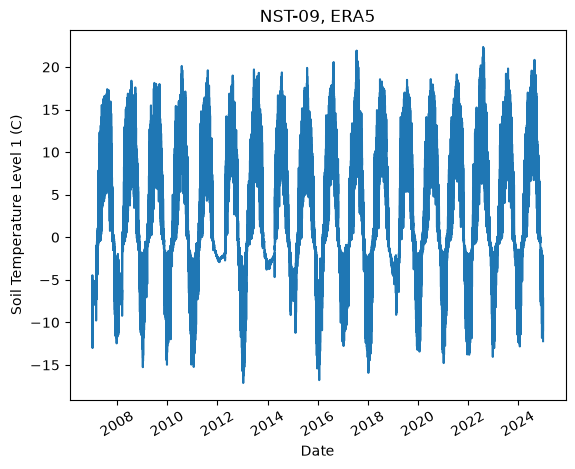

In [42]:
ERA5_NST_09_df = data_cleaning(data_path=nb_vars.raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=StationName.NST_09,
                               system=nb_vars.ERA5,
                               key_variable=nb_vars.ERA5_short_var_name,
                               class_boundary=c.CLASS_BOUNDARY,
                               classes=c.CLASSES,
                               date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_NST_09_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.NST_09}, {nb_vars.ERA5}")

In [43]:
# export to csv
ERA5_NST_09_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.NST_09}_{nb_vars.ERA5}.csv')

### 2.9 SOD012

#### ASCAT

There are 3793 nulls out of 37371 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,31051.000000,33660.000000,33660.000000,33660.000000
mean,-10.429147,0.453714,0.497742,3.697683
std,0.982348,0.497860,0.500002,0.737385
min,-14.228875,0.000000,0.000000,3.000000
25%,-11.064843,0.000000,0.000000,3.000000
50%,-10.253338,0.000000,0.000000,4.000000
75%,-9.675748,1.000000,1.000000,4.000000
max,-7.152429,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 08:00:00+00:00,-11.544338,1,1,3
2007-01-01 10:00:00+00:00,NaN,0,1,3
2007-01-01 19:00:00+00:00,-11.142731,1,0,3
2007-01-02 11:00:00+00:00,-11.569245,0,1,3
2007-01-02 17:00:00+00:00,-11.303937,0,0,3


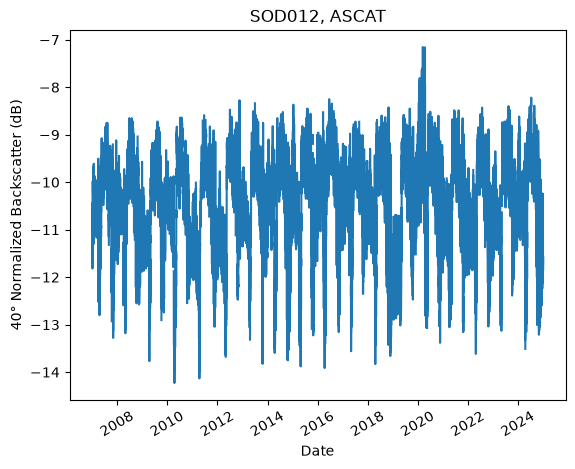

In [44]:
ASCAT_SOD012_df = data_cleaning(data_path=nb_vars.raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=StationName.SOD012,
                                system=nb_vars.ASCAT,
                                key_variable=nb_vars.ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_SOD012_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.SOD012}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

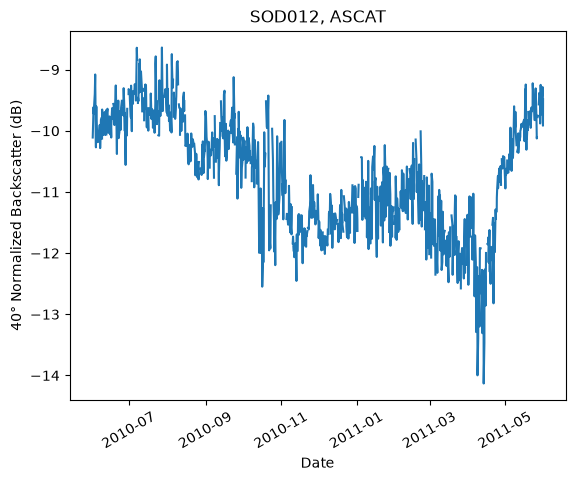

In [45]:
ax = plot_var_vs_time(ASCAT_SOD012_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.SOD012}, {nb_vars.ASCAT}")

In [46]:
# export to csv
ASCAT_SOD012_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.SOD012}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,2.821313
std,7.145260
min,-15.353729
25%,-2.311737
50%,-0.422251
75%,8.808136
max,26.531800


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-1.742340,frozen
2007-01-01 01:00:00+00:00,-1.723785,frozen
2007-01-01 02:00:00+00:00,-1.705231,frozen
2007-01-01 03:00:00+00:00,-1.686676,frozen
2007-01-01 04:00:00+00:00,-1.668121,frozen


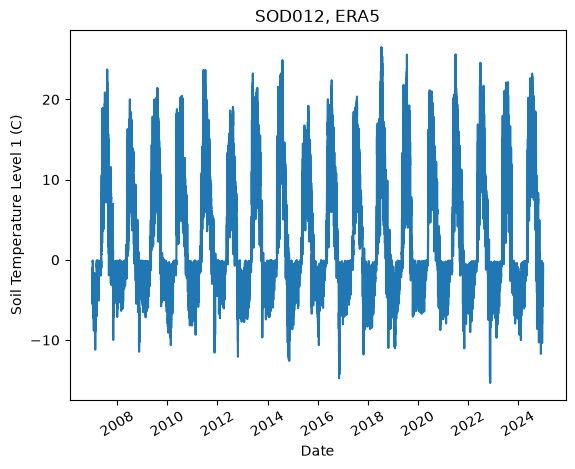

In [47]:
ERA5_SOD012_df = data_cleaning(data_path=nb_vars.raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=StationName.SOD012,
                               system=nb_vars.ERA5,
                               key_variable=nb_vars.ERA5_short_var_name,
                               class_boundary=c.CLASS_BOUNDARY,
                               classes=c.CLASSES,
                               date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_SOD012_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.SOD012}, {nb_vars.ERA5}")

In [48]:
# export to csv
ERA5_SOD012_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.SOD012}_{nb_vars.ERA5}.csv')

### 2.10 SOD103

#### ASCAT

There are 3793 nulls out of 37371 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,31051.000000,33660.000000,33660.000000,33660.000000
mean,-10.429147,0.453714,0.497742,3.697683
std,0.982348,0.497860,0.500002,0.737385
min,-14.228875,0.000000,0.000000,3.000000
25%,-11.064843,0.000000,0.000000,3.000000
50%,-10.253338,0.000000,0.000000,4.000000
75%,-9.675748,1.000000,1.000000,4.000000
max,-7.152429,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 08:00:00+00:00,-11.544338,1,1,3
2007-01-01 10:00:00+00:00,NaN,0,1,3
2007-01-01 19:00:00+00:00,-11.142731,1,0,3
2007-01-02 11:00:00+00:00,-11.569245,0,1,3
2007-01-02 17:00:00+00:00,-11.303937,0,0,3


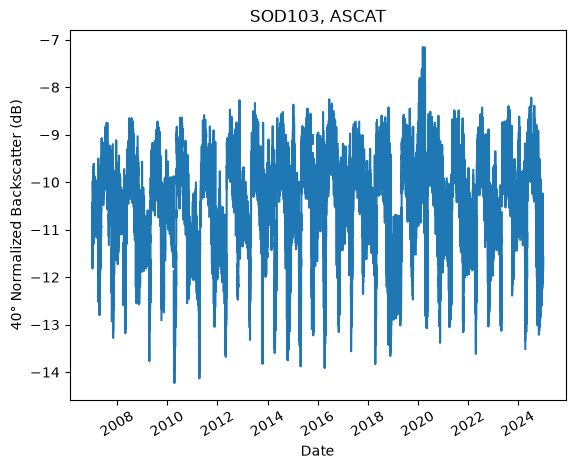

In [49]:
ASCAT_SOD103_df = data_cleaning(data_path=nb_vars.raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=StationName.SOD103,
                                system=nb_vars.ASCAT,
                                key_variable=nb_vars.ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
ax = data_reporting(df=ASCAT_SOD103_df,
                    variable=nb_vars.ASCAT_short_var_name,
                    ylabel=nb_vars.ASCAT_long_var_name)
ax = ax.set_title(f"{StationName.SOD103}, {nb_vars.ASCAT}")

Plot one year of ASCAT data to determine backscatter behavior for this location

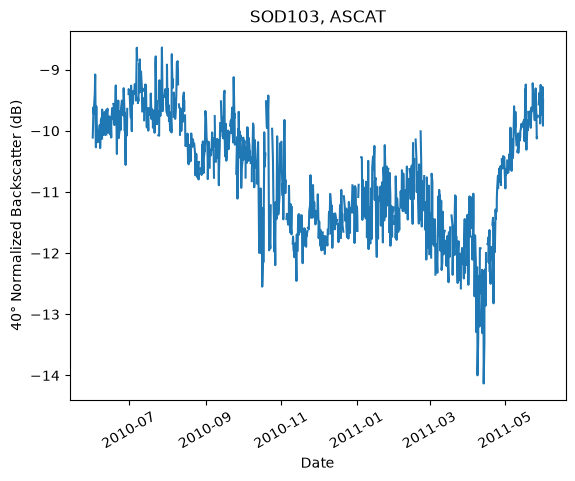

In [50]:
ax = plot_var_vs_time(ASCAT_SOD103_df, nb_vars.ASCAT_short_var_name, 'line', y_label=nb_vars.ASCAT_long_var_name,
                      start=nb_vars.START, end=nb_vars.END)
ax = ax.set_title(f"{StationName.SOD103}, {nb_vars.ASCAT}")

In [51]:
# export to csv
ASCAT_SOD103_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.SOD103}_{nb_vars.ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157801.000000
mean,2.821313
std,7.145260
min,-15.353729
25%,-2.311737
50%,-0.422251
75%,8.808136
max,26.531800


Show head of df:


,stl1,pred
UTC_timestamp,,
2007-01-01 00:00:00+00:00,-1.742340,frozen
2007-01-01 01:00:00+00:00,-1.723785,frozen
2007-01-01 02:00:00+00:00,-1.705231,frozen
2007-01-01 03:00:00+00:00,-1.686676,frozen
2007-01-01 04:00:00+00:00,-1.668121,frozen


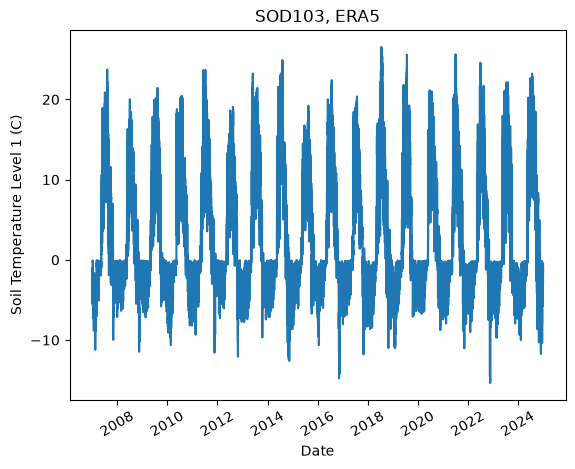

In [52]:
ERA5_SOD103_df = data_cleaning(data_path=nb_vars.raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=StationName.SOD103,
                               system=nb_vars.ERA5,
                               key_variable=nb_vars.ERA5_short_var_name,
                               class_boundary=c.CLASS_BOUNDARY,
                               classes=c.CLASSES,
                               date_range=c.DATE_RANGE)
ax = data_reporting(df=ERA5_SOD103_df,
                    variable=nb_vars.ERA5_short_var_name,
                    ylabel=nb_vars.ERA5_long_var_name)
ax = ax.set_title(f"{StationName.SOD103}, {nb_vars.ERA5}")

In [53]:
# export to csv
ERA5_SOD103_df.to_csv(c.CLEANED_DATA_PATH / f'{StationName.SOD103}_{nb_vars.ERA5}.csv')